**Imports**

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
import os

**Download Dataset**

In [2]:
import kagglehub

path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

100%|██████████| 1.03G/1.03G [00:26<00:00, 41.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1


In [3]:
asl_image_root = os.path.join(path, "asl_alphabet_train", "asl_alphabet_train")
print("Classes:", sorted(os.listdir(asl_image_root)[:]))

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


**Data Preprocessing**

In [4]:
transform=transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = datasets.ImageFolder(root=asl_image_root,transform=transform)

loader = DataLoader(dataset,batch_size=32,num_workers=2,persistent_workers=True,shuffle=True)

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Forward process and schedules**

In [6]:
class Diffusion(nn.Module):
  def __init__(self,noise_steps=1000,beta_start=1e-4,beta_end=0.02,device="cuda"):
    super().__init__()
    self.noise_steps=noise_steps
    self.img_size=32
    self.device=device
    self.beta=torch.linspace(beta_start,beta_end,noise_steps).to(device)
    self.alpha=1-self.beta
    self.alpha_hat=torch.cumprod(self.alpha,dim=0)

  def sample_timesteps(self,n):
    return torch.randint(low=1,high=self.noise_steps,size=(n,))

  def add_noise(self,x,t):
    sqrt_alpha_hat=torch.sqrt(self.alpha_hat[t])[:,None,None,None]
    sqrt_one_minus_alpha_hat=torch.sqrt(1-self.alpha_hat[t])[:,None,None,None]
    epsilon=torch.randn_like(x)
    total_noise=sqrt_alpha_hat*x+sqrt_one_minus_alpha_hat*epsilon
    return total_noise,epsilon

  @torch.no_grad()
  def sample(self,model,n,labels):
    model.eval()
    x=torch.randn(n,3,self.img_size,self.img_size,device=self.device)
    for i in reversed(range(1,self.noise_steps)):
      t=torch.full((n,),i,dtype=torch.long,device=self.device)
      predicted_noise=model(x,t,labels)
      alpha=self.alpha[t][:,None,None,None]
      alpha_hat=self.alpha_hat[t][:,None,None,None]
      beta=self.beta[t][:,None,None,None]
      noise=torch.randn_like(x) if i>1 else torch.zeros_like(x)
      x=1/torch.sqrt(alpha)*(x-((1-alpha)/torch.sqrt(1-alpha_hat))*predicted_noise)+torch.sqrt(beta)*noise
    model.train()
    x=(x.clamp(-1,1)+1)/2
    return x

**Defining Model**

In [7]:
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class Down(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.model = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_c, out_c)
        )

    def forward(self, x):
        return self.model(x)


class Up(nn.Module):

    def __init__(self, in_c,skip_c, out_c):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_c,
            in_c // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_c // 2 + skip_c, out_c)

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)

**UNet Architecture**

In [8]:
class UNet(nn.Module):
  def __init__(self,num_classes,time_dim=256):
    super().__init__()

    self.time_emb=nn.Embedding(1000,time_dim)
    self.label_emd=nn.Embedding(num_classes,time_dim)

    self.initial=DoubleConv(3,64)
    self.d1=Down(64,128)
    self.d2=Down(128,256)
    self.d3=DoubleConv(256,512)
    self.up1=Up(512,128,256)
    self.up2=Up(256,64,128)

    self.out=nn.Conv2d(128,3,kernel_size=1)
    self.embed_proj=nn.Linear(time_dim,512)

  def forward(self,x,t,y):
    x1=self.initial(x)
    x2=self.d1(x1)
    x3=self.d2(x2)
    emd=self.time_emb(t)+self.label_emd(y)
    emd=self.embed_proj(emd)
    emd=emd[:,:,None,None]
    x4=self.d3(x3)
    x4=x4+emd
    x=self.up1(x4,x2)
    x=self.up2(x,x1)
    x=self.out(x)
    return x

**Hyperparameters**


In [9]:
num_classes=len(dataset.classes)
model=UNet(num_classes).to(device)
diffusion=Diffusion(device=device)
optimizer=torch.optim.Adam(model.parameters(),lr=3e-4)
mse=nn.MSELoss()
epochs=150

**Saving Checkpoints to Drive**



In [10]:
from google.colab import drive
drive.mount('/content/drive')
CKPT_DIR = "/content/drive/MyDrive/asl_diffusion"
os.makedirs(CKPT_DIR, exist_ok=True)

Mounted at /content/drive


Full Training Loop

In [12]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

class_names=dataset.classes

os.makedirs("checkpoints", exist_ok=True)
best_loss=float("inf")
sample_every=10
n_samples=5
fixed_labels=torch.arange(n_samples,device=device)%num_classes
history=[]

start_epoch = 100
last_path = f"{CKPT_DIR}/last.pth"
if os.path.exists(last_path):
    ckpt = torch.load(last_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_loss = ckpt.get("best_loss", float("inf"))
    print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):

    pbar=tqdm(loader)
    running_loss=0.0; n_batches=0

    for images,labels in pbar:

        images=images.to(device)
        labels=labels.to(device)

        t=diffusion.sample_timesteps(
            images.shape[0]
        ).to(device)

        x_t,noise=diffusion.add_noise(images,t)

        pred_noise=model(x_t,t,labels)

        loss=mse(pred_noise,noise)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        running_loss+=loss.item(); n_batches+=1
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / n_batches
    print(f"Epoch {epoch} | avg loss: {avg_loss:.4f}")

    ckpt = {"epoch": epoch, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "avg_loss": avg_loss, "best_loss": best_loss}
    torch.save(ckpt, f"{CKPT_DIR}/last.pth")
    if (epoch+1) % sample_every == 0:
        torch.save(ckpt, f"{CKPT_DIR}/checkpoint_epoch_{epoch}.pth")
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), f"{CKPT_DIR}/best_model.pth")
        print("  new best -> best_model.pth")

    if (epoch+1) % sample_every == 0:
        torch.manual_seed(42)
        samples = diffusion.sample(model, n_samples, fixed_labels)
        grid = make_grid(samples, nrow=n_samples, padding=2).cpu()
        history.append((epoch, grid))
        plt.figure(figsize=(10, 2.2))
        plt.imshow(grid.permute(1, 2, 0).numpy()); plt.axis("off")
        plt.title(f"Epoch {epoch}")
        plt.show()

Resumed from epoch 150


**Visulizations and Model Output**

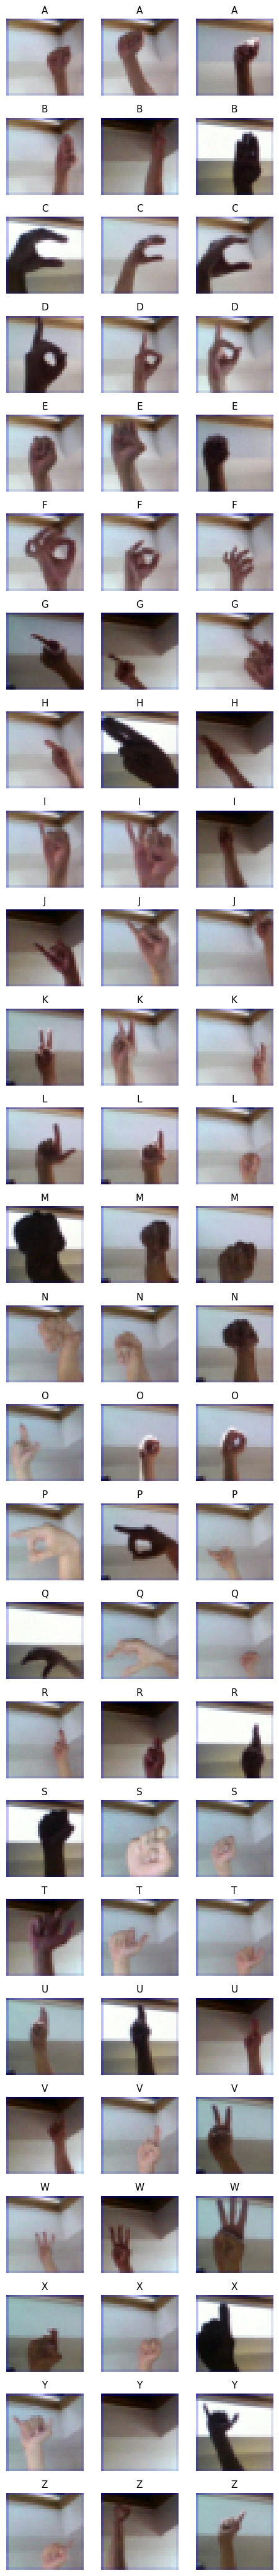

In [15]:
import matplotlib.pyplot as plt
import torch

model = UNet(num_classes).to(device)
model.load_state_dict(torch.load(f"{CKPT_DIR}/best_model.pth", map_location=device))
model.eval()
diffusion = Diffusion(device=device)

letters = [chr(c) for c in range(ord("A"), ord("Z") + 1)]
per_letter = 3

labels = torch.tensor(
    [dataset.classes.index(L) for L in letters for _ in range(per_letter)],
    device=device
)

torch.manual_seed(42)
samples = diffusion.sample(model, len(labels), labels)
imgs = samples.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(len(letters), per_letter,
                         figsize=(per_letter * 1.6, len(letters) * 1.6))
for r, L in enumerate(letters):
    for c in range(per_letter):
        ax = axes[r, c]
        ax.imshow(imgs[r * per_letter + c])
        ax.set_title(L, fontsize=11)
        ax.axis("off")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/showcase_A_to_Z.png", dpi=150, bbox_inches="tight")
plt.show()